## Proceso de adimensionalización
### Juan S. Hincapié - Carlos Duque-Daza

### Homogeneidad dimensional

<div align='justify'>Seguramente cuando estabas aprendiendo los principios del álgebra te dijeron "No se pueden sumar peras con manzanas". Un clásico ¿Verdad? En realidad, esta expresión proviene de una ley matemática más global y de caracter funadamental para las ecuaciones: la <b>Ley de homogeneidad dimensional</b>. Esta ley dice lo siguiente: </div>

<div align='center'> Todo término aditivo en una ecuación debe tener las mismas dimensiones. </div><br>

<div align='justify'> Verifiquemos este con alguna ecuación, como por ejemplo, la ecuación de movimiento que describe el descenso de un objeto que cae por la gravedad a través de un vacío (sin resistencia del aire) desde una altura $z$ es:</div>

 $$
     {\frac{d^{2}z}{d t^{2}}}=-g
 $$

 <br>

<div align='justify'>A continuación un esquema que representa el caso anteriormente descrito.</div>

 <img src=https://raw.githubusercontent.com/juhincapiem/ModMat/refs/heads/main/Diagrams/caidaLibre.png alt="Elefante en caída libre"  width="400"  />



<div class="alert alert-block alert-warning">
<b> ¿Se cumple la Ley de homogeneidad universal para esta ecuación diferencial?</b>
</div>

Efectivamente:

$$
\left[\frac{L}{T^2}\right] = \left[\frac{L}{T^2}\right]
$$

### Eliminación de dimensiones

<div align='justify'>Ya sabemos que la Ley de homogeneidad dimensional asegura que cada uno de los término que se suman en una ecuación deben tener las mismas dimensiones. ¿Qué ocurre si cada término en la ecuación se divide entre un conjunto de variables y constantes cuyo producto tenga estas mismas dimensiones? Pues la ecuación queda sin dimensiones, es decir, <b>adimensionalizada</b>. Si, además, los términos adimensionales en la ecuación son de magnitud uno, entonces la ecuación se llama <b>normalizada</b>. </div>

Miremos los pasos para adimensionalizar una ecuación diferencial:

<div class="alert alert-block alert-info">
<b> ¿Qué variables se adimensionalizan? Tanto las variables independiente como las dependientes</b>
</div>

Para este caso tenemos una variable independiente, el tiempo $t$, y una variable dependiente, la altura $z$.


<div class="alert alert-block alert-info">
<b> Debemos proponer constantes características:</b>
</div>

\begin{array}{cc}
Tiempo~(t) & Altura~(z)\\
t^* = \frac{t}{t_c} & z^* = \frac{z}{z_c}
\end{array}

¿Cuáles podrían ser esos parámetros característicos? Podríamos usar la altura inicial $z_0$ y un tiempo $z_0/w_0$, donde $w_0$ es la velocidad inicial.

<div class="alert alert-block alert-info">
<b> Ya tenemos claro nuestros parámetros característicos y nuestras variables adimensionales. Ahora, ¿Cómo reemplazamos esto en una derivada?</b>
</div>

$$
    t = t_c \times t^* \rightarrow dt = t_c \times dt^*
$$

¿Volvemos a derivar para obtener $dt^2$? ¡¡¡No!!! Ya no hace falta derivar, simplemente elevamos al cuadrado toda la ecuación.

$$
    dt^2 = t_c^2 \times dt^{*2}
$$

Para la altura tenemos el siguiente procedimiento:

$$
    z = z_c \times z^* \rightarrow dz = z_c \times dz^*
$$

¿Elevamos al cuadrado...? ¡¡¡No!!! Para este caso no se debe elevar al cuadrado, simplemente derivamos nuevamente.

$$
     d^2 z = z_c \times d^2z^*
$$

<div class="alert alert-block alert-info">
<b> Ahora sí podemos hacer el reemplazo de las variable dimensionales: </b>
</div>

$$
\frac{z_c}{t_c^2}\frac{d^2z^*}{dt^{*2}} = -g
$$

Cambiamos los parámetros característicos por sus definiciones:

$$
\frac{z_0 w_0^2}{z_0^2}\frac{d^2z^*}{dt^{*2}} = -g
$$

Despejamos la derivada de segundo orden adimensional:

$$
\frac{d^2z^*}{dt^{*2}} = -\frac{z_0 g}{w_0^2}
$$

Al lado derecho tenemos el cuadrado de un conocido número adimensional, número de **Froude**. Este número compara la fuerza inercial con la fuerza gravitacional:

$$
    Fr = \frac{w_0}{\sqrt{z_0g}}
$$

Por lo tanto, nuestra ecuación diferencial ordinaria adimensional queda como:

$$
\frac{d^2z^*}{dt^{*2}} = -\frac{1}{{Fr}^2}
$$

### Propuesta
Esta Ecuación Diferencial Ordinaria se puede resolver analítica o numéricamente. Se podría plantear una solución analítica para estudiar las ventajas de la adimensionalización. La solución analítica es:

$$
    z^*(t^*) =  \frac{z_0}{|z_0|} + \frac{w_0}{|w_0|}t^* - \frac{1}{2 {Fr}^2} t^{*2}
$$

Y está implementada en **caida_libre**. La función requiere de cuatro parámetros: $Fr$, $w_0$, $g$ y el $\Delta t$. Según este planteamiento del problema, el valor de la posición inicial no se define inicialemente, se calcula a partir de los valores de los parámetros:

$$
    z_0 = \frac{w_0^2}{g{Fr}^2}
$$


### Caso de estudio

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Mi Práctica

In [16]:
# caida_libre(Fr, w0, g, deltaT)
Fr = 1
w0 = 2.0
g = 9.81
dt = 0.02

In [17]:
#Paso 01: Definir el nombre de la función: caida_libre(Fr,w0,g,deltaT)
def caida_libre_an(Fr, w0, g):
    # Paso 02: Como se ingresa Fr, W0 y g, entonces calculo el z0
    z0 = (w0**2) / (g*Fr**2)
    # Paso 03: Empleo la fórmula del tiempo final, pero ¡adimensional!
    coeficientes = [-1/(2*Fr**2),w0/abs(w0),z0/abs(z0)]
    tf = bhaskara(coeficientes[0],coeficientes[1],coeficientes[2])
    # Paso 04: Parámetros característicos del tiempo
    zc= z0
    tc = z0/w0
    # Paso 05: Se tiene el tf dimensional y el tc. Ya se puede adimensionalizare
    # Paso 06: Creo vectores de tiempo adimensional, velocidad y posición
    t_adim = np.linspace(0,tf,100)
    n = len(t_adim)
    z_adim = np.zeros(n)
    # Paso 07: Ingreso la condición inicial para la posición
    z_adim[0] = z0 / abs(z0)
    # Paso 08: Llenamos el vector de posición adimensional
    for i in range(n):
        z_adim[i] = z0 / abs(z0) + (w0*t_adim[i])/abs(w0) - (t_adim[i]**2)/(2*Fr**2)
    # Paso 09: Devolvemos los valores necesarios
    return z_adim, t_adim, tf, zc, tc
# Podemos definir, para mayor facilidad, una función que devuelva únicamente el tiempo final
def bhaskara(a,b,c):
    raiz1 = (-b+np.sqrt(b**2-4*a*c))/(2*a)
    raiz2 = (-b-np.sqrt(b**2-4*a*c))/(2*a)
    if raiz1 > 0:
      raiz = raiz1
    if raiz2 > 0:
      raiz = raiz2
    return raiz

# Gráfica

In [18]:
z_adim, t_adim, tf, zc, tc = caida_libre_an(Fr,w0,g)

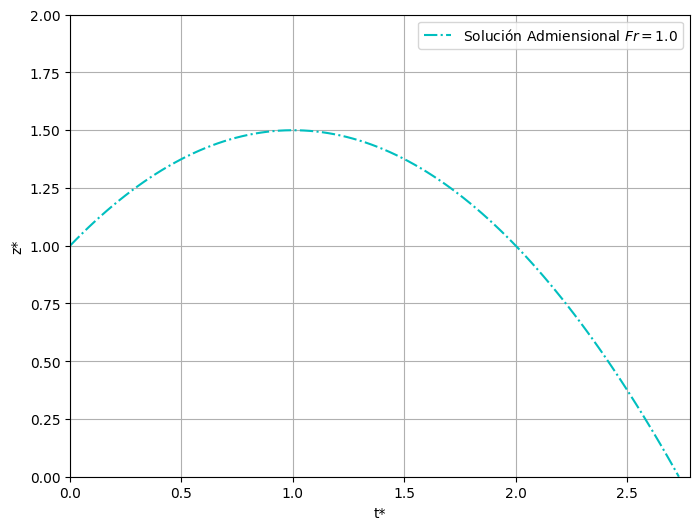

In [19]:
fig, ax = plt.subplots(1, 1, figsize = (8,6), dpi = 100)
ax.plot(t_adim, z_adim, '-.c', label = r'Solución Admiensional $Fr = 1.0 $')
ax.set_xlabel('t*')
ax.set_ylabel('z*')
ax.axis([0,tf+0.05,0,2])
ax.grid()
ax.legend()

Volver a dimenisones

Partiendo


$t = t_c \times t^* ⟹ z = z_c \times z^* $

donde

$t_c = \dfrac{z_0}{w_0} \Longrightarrow z_c = z_0$

Donde nuestros parametros adimensionales como comentamos no tienen dimensiones, por ende si hacemos esto volvemos a las dimensiones

In [20]:
t = tc * t_adim; z = zc * z_adim
## Calculo Tiempo Real
tf_dim = bhaskara((-1/2)*g,w0,zc)
print(f'{tf_dim:.3f}')

0.557


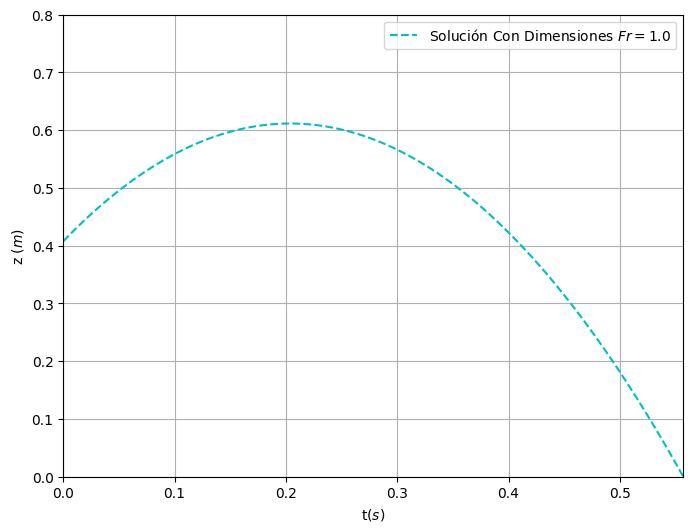

In [21]:
fig, ax = plt.subplots(1, 1, figsize = (8,6), dpi = 100)
ax.plot(t, z, '--c', label = r'Solución Con Dimensiones $Fr = 1.0 $')
ax.set_xlabel('t$(s)$')
ax.set_ylabel('z $(m)$')
ax.axis([0,tf_dim,0,0.8])
ax.grid()
ax.legend()

## Práctica en clases


In [22]:
#Paso 01: Definir el nombre de la función: caida_libre(Fr,w0,g,deltaT)
def caida_libre(Fr, v0, g):
    # Paso 02: Como se ingresa Fr, W0 y g, entonces calculo el z0
    x0=v0**2/(g*Fr**2)
    print(x0)
    # Paso 03: Empleo la fórmula del tiempo final, pero ¡Dimensional!
    coefPoli = [-1/(2*Fr**2),v0/abs(v0),x0/abs(x0)] #ax^2,bx,c
    poli = np.poly1d(coefPoli)
    print(poli)
    print(poli.roots)
    t_f=0
    for i in poli.roots:
      if i>0:
        print(i)
        t_f=i
    print(f'el tiempo en el que va a tocar el suelo {t_f}')
    # Paso 04: Parámetros característicos del tiempo
    xc=x0
    tc=(x0/v0)
    # Paso 05: Se tiene el tf dimensional y el tc. Ya se puede adimensionalizare

    # Paso 06: Creo vectores de tiempo adimensional, velocidad y posición
    t_adim = np.linspace(0,t_f,100)
    #print(t_adim)
    x_adim = np.zeros(len(t_adim))
    # Paso 07: Ingreso la condición inicial para la posición
    x_adim[0] =x0/abs(x0)
    print(x_adim)
    # Paso 08: Llenamos el vector de posición adimensional
    n =len(x_adim)
    for i in range(1,len(x_adim)):
      x_adim[i]=x0/abs(x0)+v0/abs(v0)*t_adim[i]-1/(2*Fr**2)*t_adim[i]**2
    #print(x_adim)
    # Paso 09: Devolvemos los valores necesarios
    return x_adim, t_adim, t_f,zc,tc
# Podemos definir, para mayor facilidad, una función que devuelva únicamente el tiempo final
def tiempo_final(x0, v0, g):
    a = 0.5*g; b = v0; c = x0
    tf = (-b - np.sqrt(b**2-4*a*c))/(2*a)
    return tf


<div class="alert alert-block alert-info">
<b> ¿Cuál sería la gráfica de $z^*$ vs $t^*$? $Fr = 1.0$, $w_0 = 2.0 m/s$ y $g = -9.81 m/s^2$ </b>
</div>

In [23]:
# caida_libre(Fr, w0, g, deltaT)
Fr = 1.0
v0 = 2.0
g = 9.81
dt = 0.001

#zAdim,tAdim,zc,tc = caida_libre(Fr, w0, g, dt)
x_adim, t_adim, t_f,xc,tc = caida_libre(Fr,v0,g)

0.4077471967380224
      2
-0.5 x + 1 x + 1
[ 2.73205081 -0.73205081]
2.732050807568877
el tiempo en el que va a tocar el suelo 2.732050807568877
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [24]:
x_axis = t_adim
y_axis = x_adim

<div class="alert alert-block alert-info">
<b> Al inicio puede ser un poco confuso entender la gráfica adimensional, ¿Qué tal si le devolvemos las dimensiones? </b>
</div>

¡Es muy fácil! Sólo hay que retomar las expresiones adimensionales:

\begin{array}{cc}
Tiempo~(t) & Altura~(z)\\
t^* = \frac{t}{t_c} & z^* = \frac{z}{z_c}
\end{array}

Despejamos $t$ y $z$ de las expresiones anteriores:

$$
    t = t_{c} \times t^*
$$

$$
    z = z_{c} \times z^*
$$



Método profesor

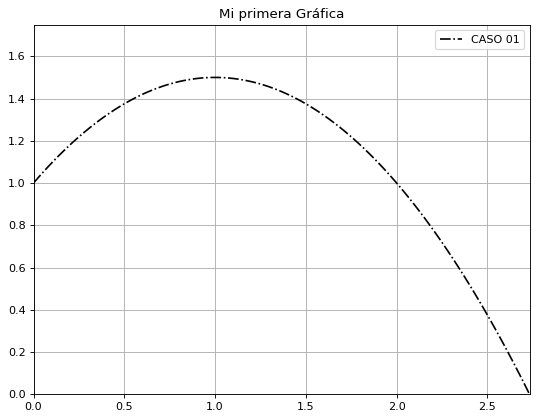

In [25]:
fig, ax = plt.subplots(1,1, figsize = (8,6), dpi = 80)
ax.set_title('Mi primera Gráfica')
# Leyendas
ax.plot(x_axis,y_axis,'k-.', label = "CASO 01")
ax.set_xlim([0,t_f])
ax.set_ylim([0,1.75])
plt.legend()
ax.grid()

Y 3 ejes?

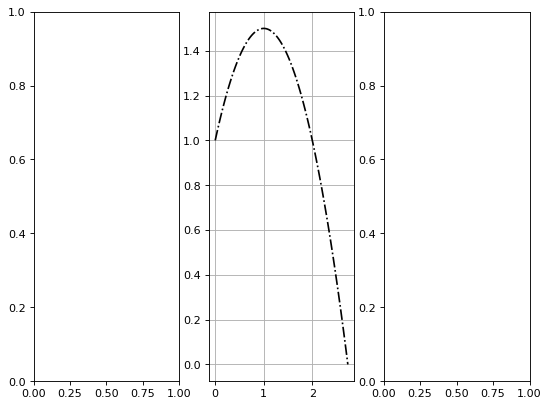

In [26]:
fig, ax = plt.subplots(1,3, figsize = (8,6), dpi = 80)
ax[1].plot(x_axis,y_axis,'-.k')
ax[1].grid()

In [27]:
t = t_adim*tc
x = x_adim*xc

In [28]:
tc

0.2038735983690112

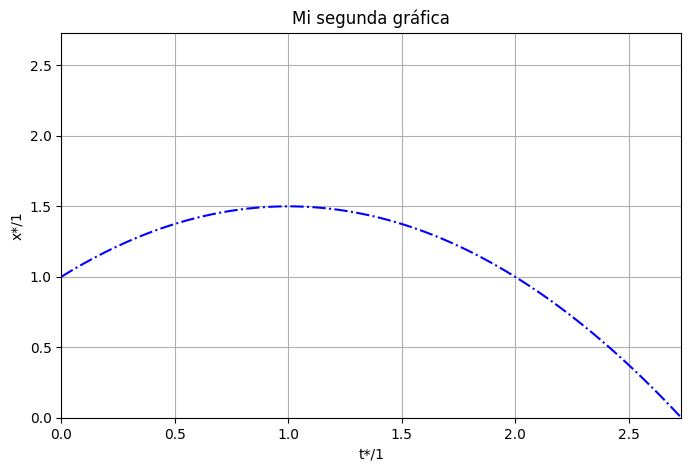

In [29]:
plt.figure(figsize = (8,5))
plt.title('Mi segunda gráfica')
plt.ylabel("x*/1")
plt.xlabel("t*/1")
plt.xlim([0,t_f])
plt.ylim([0,t_f])
plt.plot(x_axis,y_axis,'b-.',label = 'Caso 01')
plt.legend
plt.grid()
plt.show()

Volver a las dimensiones

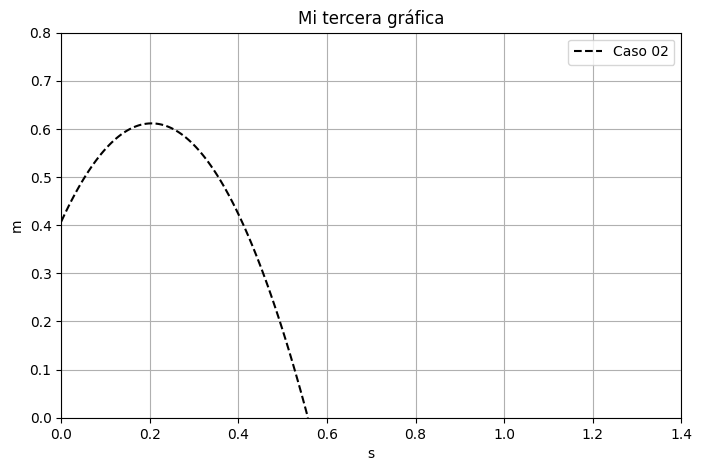

In [30]:
plt.figure(figsize = (8,5))
plt.title('Mi tercera gráfica')
plt.ylabel("m")
plt.xlabel("s")
plt.xlim([0,1.4])
plt.ylim([0,0.8])
plt.plot(t,x,'k--', label='Caso 02')
plt.legend()
plt.grid()
plt.show()

<div class="alert alert-block alert-info">
Podemos validar el resultado calculando el tiempo final del movimiento. La ecuación está implementada en la función <b> tiempo_final</b>
</div>

In [31]:
x0 = v0**2/(g*Fr**2)
def tiempo_final(x0, v0, g):
    a = -0.5*g; b = v0; c = x0
    tf = (-b - np.sqrt(b**2-4*a*c))/(2*a)
    return tf
tf = tiempo_final(x0, v0, g)
print("El tiempo final es: {:.3f}".format(tf))

El tiempo final es: 0.557


### Racapitulemos

<div align='justify'> Hagamos un breve resumen de lo que hemos hecho hasta este momento:</div>

1. Plantear la ecuación de movimiento de proyectil que es lanzando verticalmente.

1. Hacer un proceso de adimensionalización de la EDO.

1. Resolver analíticamente la EDO adimensional.

1. Graficar $z^*$ vs $t^*$.

1. También se graficó $z$ vs $t$.

1. Por último, se validó el resultado, a través del cálculo del tiempo final.


<div class="alert alert-block alert-warning">
<b> Y todo esto... ¿Para qué? Pareciera que se pasó por mucha algebra para obtener el mismo resultado dimensional ¿De qué sirve hacer todo esto? </b>
</div>

### Ventajas

<div align='justify'> El proceso de adimensionalizar trae consigo dos ventajas principales:</div>

1. Reduce el número de parámetros en los experimentos.
1. Brinda una mejor comprensión de cómo se relacionan los parámetros claves del experimento.


### Ejercicio

<div align='justify'>El fabricante de balones de fútbol <b>"Junior tu papá"</b> solicitó tres experimentos de movimiento vertical a diferentes condiciones, $w_0$,$z_0$ y $g$, para un nuevo prototipo de balón recientemente diseñado. Lo valores de las condiciones de cada uno de los tres experimentos se presentan en la tabla. Estos se llevarán a cabo en un tubo vertical grande cuyo interior se mantiene a condiciones de vacío. El director de la fábrica solicita  dos cosas: el tiempo final del movimiento vertical, y la gráfica de altura vs tiempo. </div>


| Parámetro | Experimento 01 | Experimento 02 | Experimento 03 |
| --- | --- |  --- |  --- |
| $w_0~[m/s]$ | -2.0 |  -4.0 | -1.83 |
| $z_0~[m]$ | 0.4077 |  1.6308 | 2.0 |
| $g~[m/s^2]$ | -9.81 | -9.81 | -1.674 |
| $t_f~[s]$| 0.149 | 0.298 | 0.800 |

<div class="alert alert-block alert-info">
<b> Calcular el tiempo final.</b> Usando la función <b>tiempo_final</b> se puede obtener el tiempo final para cada uno de los experimentos.
</div>

In [32]:
valores_exp = [[-2.0, 0.4077, -9.81],[-4.0, 1.6308, -9.81],[-1.83, 2, -1.674]] # w0, z0, g



In [33]:
def bhaskara(a,b,c):
    raiz1 = (-b + np.sqrt(b**2-4*a*c))/(2*a)
    raiz2 = (-b - np.sqrt(b**2-4*a*c))/(2*a)
    if raiz1 > 0:
      raiz = raiz1
    if raiz2 > 0:
      raiz = raiz2
    return raiz

In [34]:
def tiempo_final(x0, v0, g):
    a = 0.5*g; b = v0; c = x0
    tf = (-b - np.sqrt(b**2-4*a*c))/(2*a)
    return tf


In [35]:
# tiempo_final(z0,w0,g)
lista_tf = []
for i in range(len(valores_exp)):
  t_f = bhaskara(0.5*valores_exp[i][2], valores_exp[i][0], valores_exp[i][1])
  print(f'El tiempo final de  los experimentos debería ser: {t_f:.3f}')
  lista_tf.append(t_f)

El tiempo final de  los experimentos debería ser: 0.149
El tiempo final de  los experimentos debería ser: 0.298
El tiempo final de  los experimentos debería ser: 0.800


<div class="alert alert-block alert-info">
<b> Graficar los tres casos.</b> Para esto se puede emplear la siguiente ecuación:
</div>

$$
    z = z_0 + w_0 \times t + \frac{1}{2}\times g \times t^2
$$

In [36]:
# Paso 01: definimos una función que contenga tf, z0, w0, g, dt
def posicion(tf, z0, w0, g):

    # Paso 02: Crear vector de tiempo
    vect_t = np.linspace(0,tf,100)
    n = len(vect_t)
    # Paso 03: Inicializar vector de posición
    z = np.zeros(n)

    # Paso 04: Incluir la condición incial en el vector de posición
    z[0] = z0
    # Paso 05: implementar ciclo for
    for i in range(n):
        z[i] = z0 + w0*vect_t[i] + 0.5*g*vect_t[i]**2
    return vect_t, z

In [37]:
lista_tf[0]
valores_exp[2][2]

-1.674

In [38]:
# Paso 06: usamos la función para obtener las posición y el tiempo
t1, z1 = posicion(lista_tf[0], valores_exp[0][1], valores_exp[0][0], valores_exp[0][2])
t2, z2 = posicion(lista_tf[1], valores_exp[1][1], valores_exp[1][0], valores_exp[1][2])
t3, z3 = posicion(lista_tf[2], valores_exp[2][1], valores_exp[2][0], valores_exp[2][2])

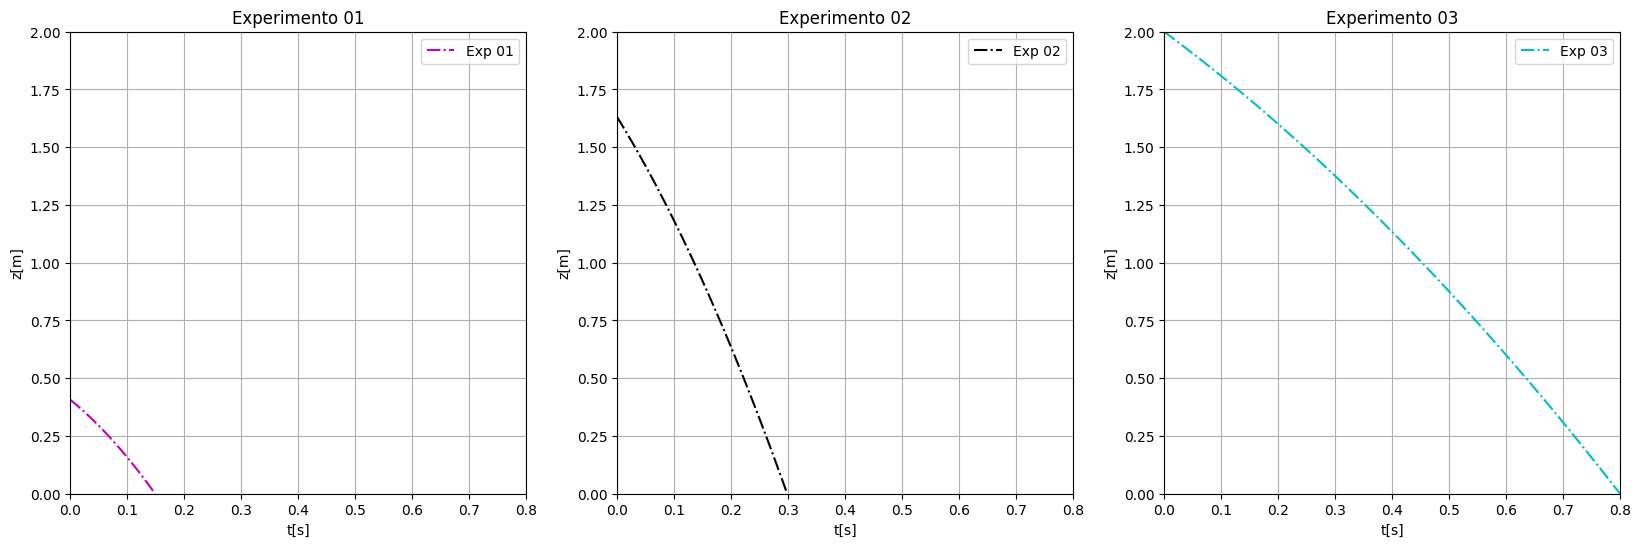

In [39]:
# Paso 07: Graficamos
fig, ax = plt.subplots(1, 3, figsize = (20,6), dpi=100)
for i in range(3):
  ax[i].grid()
  ax[i].set_title(f'Experimento 0{i+1}')
  ax[i].set_xlim([0,0.8])
  ax[i].set_ylim([0,2])
  ax[i].set_xlabel('t[s]')
  ax[i].set_ylabel('z[m]')
# Exp 01
ax[0].plot(t1, z1, 'm-.', label = 'Exp 01')
ax[0].legend()
# Exp 02
ax[1].plot(t2, z2, 'k-.', label = 'Exp 02')
ax[1].legend()
# Exp 03
ax[2].plot(t3, z3, 'c-.', label = 'Exp 03')
ax[2].legend()

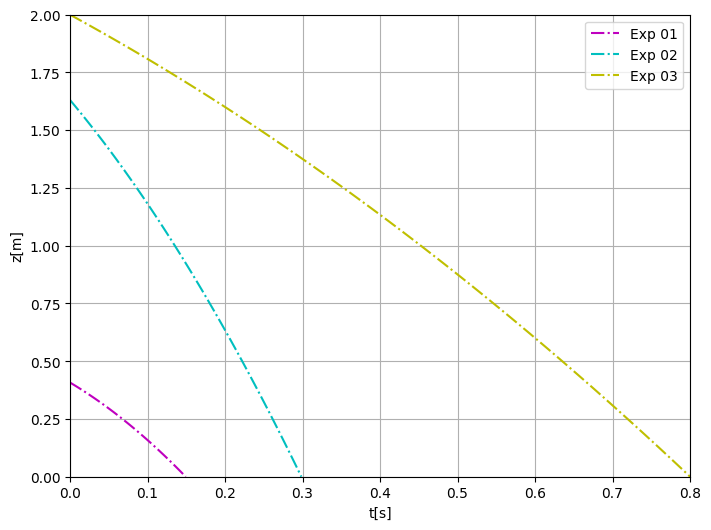

In [40]:
# Paso 07: Graficamos (Todo en una sola gráfica)
fig, ax = plt.subplots(1, 1, figsize = (8,6), dpi=100)
ax.plot(t1, z1, 'm-.', label = 'Exp 01')
ax.plot(t2, z2, 'c-.', label = 'Exp 02')
ax.plot(t3, z3, 'y-.', label = 'Exp 03')
ax.set_xlabel('t[s]')
ax.set_ylabel('z[m]')
ax.set_xlim([0,0.8])
ax.set_ylim([0,2])
ax.legend()
ax.grid()

<div align='justify'>¡Listo! ya tenemos nuestros resultados y podemos mostrarselos al director de la empresa... Pero de repente se nos ocurre la brillante idea de adimensionalzar la EDO y resolverla para ver qué pasa ¿Ocurriría algo distinto?. </div>

<div class="alert alert-block alert-info">
<b> Calcular los parámetros característicos.</b> Luego de calcular el tiempo final $t_f$ para cada uno de los casos, proceda a calcular sus parámetros característicos:
</div>

$$
    {F_r}^2 = \frac{{w_0}^2}{z_0g},~z_c = z(0) = z_0, t_c = \frac{z_0}{w_0}
$$

<div class="alert alert-block alert-info">
<b> Llenar la tabla siguiente tabla.</b>
</div>

| Parámetro | Caso 01 | Caso 02 | Caso 03 |
| --- | --- |  --- |  --- |
| $F_r^2$ | 1.0  | 1.0 | 1.0 |
| $z_c~[m]$ | 0.4077 | 1.6308 | 2.0 |
| $t_c~[s]$ | 0.2038 | 0.4077 | 1.092 |


<div class="alert alert-block alert-info">
<b> ¿Qué podemos notar de los tres experimentos? ¿Qué tienen en común?</b> ¡Así es! Y de este resultado podemos sacar mucho provecho. Reutilicemos la función <b>caida_libre</b> para obtener $z^*$ y $t^*$ y graficarlo
</div>


In [41]:
#Paso 01: Definir el nombre de la función: caida_libre(Fr,w0,g,deltaT)
def caida_libre_an(Fr, w0, g):
    # Paso 02: Como se ingresa Fr, W0 y g, entonces calculo el z0
    z0 = (w0**2) / (g*Fr**2)
    # Paso 03: Empleo la fórmula del tiempo final, pero ¡adimensional!
    coeficientes = [-1/(2*Fr**2),w0/abs(w0),z0/abs(z0)]
    tf = bhaskara(coeficientes[0],coeficientes[1],coeficientes[2])
    # Paso 04: Parámetros característicos del tiempo
    zc= z0
    tc = z0/abs(w0)
    # Paso 05: Se tiene el tf dimensional y el tc. Ya se puede adimensionalizare
    # Paso 06: Creo vectores de tiempo adimensional, velocidad y posición
    t_adim = np.linspace(0,tf,100)
    n = len(t_adim)
    z_adim = np.zeros(n)
    # Paso 07: Ingreso la condición inicial para la posición
    z_adim[0] = z0 / abs(z0)
    # Paso 08: Llenamos el vector de posición adimensional
    for i in range(n):
        z_adim[i] = z0 / abs(z0) + (w0*t_adim[i])/abs(w0) - (t_adim[i]**2)/(2*Fr**2)
    # Paso 09: Devolvemos los valores necesarios
    return z_adim, t_adim, tf, zc, tc
# Podemos definir, para mayor facilidad, una función que devuelva únicamente el tiempo final
def bhaskara(a,b,c):
    raiz1 = (-b+np.sqrt(b**2-4*a*c))/(2*a)
    raiz2 = (-b-np.sqrt(b**2-4*a*c))/(2*a)
    if raiz1 > 0:
      raiz = raiz1
    if raiz2 > 0:
      raiz = raiz2
    return raiz

In [42]:
# Ingresamos los parámetros a la función ¿Cuáles?
valores_exp = [[-2.0, 0.4077, -9.81],[-4.0, 1.6308, -9.81],[-1.83, 2, -1.674]] # w0, z0, g
parametros = [[1.0,0.4077,0.2038],[1.0,1.6308,0.4077],[1.0,2.0,1.092]] # Fr, zc, tc
g = 9.81
z_adim1, t_adim1, tf1, zc1, tc1 = caida_libre_an(1,-2,g)
z_adim2, t_adim2, tf2, zc2, tc2 = caida_libre_an(1,-4,g)
z_adim3, t_adim3, tf3, zc3, tc3 = caida_libre_an(1,-1.83,-valores_exp[2][2])

# El profe quiere ver la gráfica


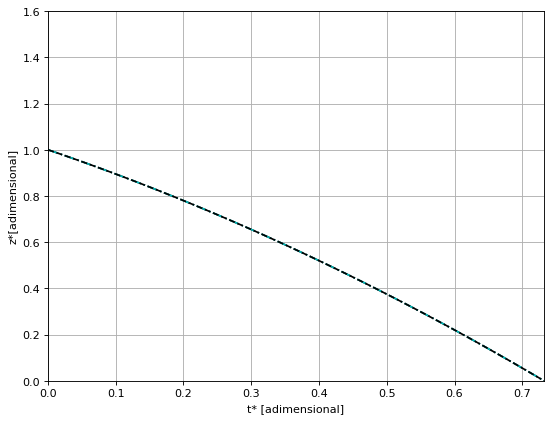

In [43]:
fig , ax = plt.subplots(1,1,figsize = (8,6), dpi = 80)
ax.plot(t_adim1, z_adim1, 'k-.')
ax.plot(t_adim2, z_adim2, 'c-.')
ax.plot(t_adim3, z_adim2, 'k--')
ax.set_xlim([0,tf1])
ax.set_ylim([0,1.6])
ax.set_xlabel('t* [adimensional]')
ax.set_ylabel('z*[adimensional]')
ax.grid()

<div class="alert alert-block alert-info">
<b> ¿Recuerdan qué se hace para pasar una gráfica sin dimensiones a una con dimensiones?</b>
</div>

\begin{array}{cc}
Tiempo~(t) & Altura~(z)\\
t^* = \frac{t}{t_c} & z^* = \frac{z}{z_c}
\end{array}

Despejamos $t$ y $z$ de las expresiones anteriores:

$$
    t = t_{c} \times t^*
$$

$$
    z = z_{c} \times z^*
$$

Multiplicamos los vectores $z^*$ y $t^*$ por los parámetros característicos para devolver las dimensiones.

| Parámetro | Caso 01 | Caso 02 | Caso 03 |
| --- | --- |  --- |  --- |
| $F_r^2$ | 1.0  | 1.0 | 1.0 |
| $z_c~[m]$ | 0.4077 | 1.6308 | 2.0 |
| $t_c~[s]$ | 0.2038 | 0.4077 | 1.092 |


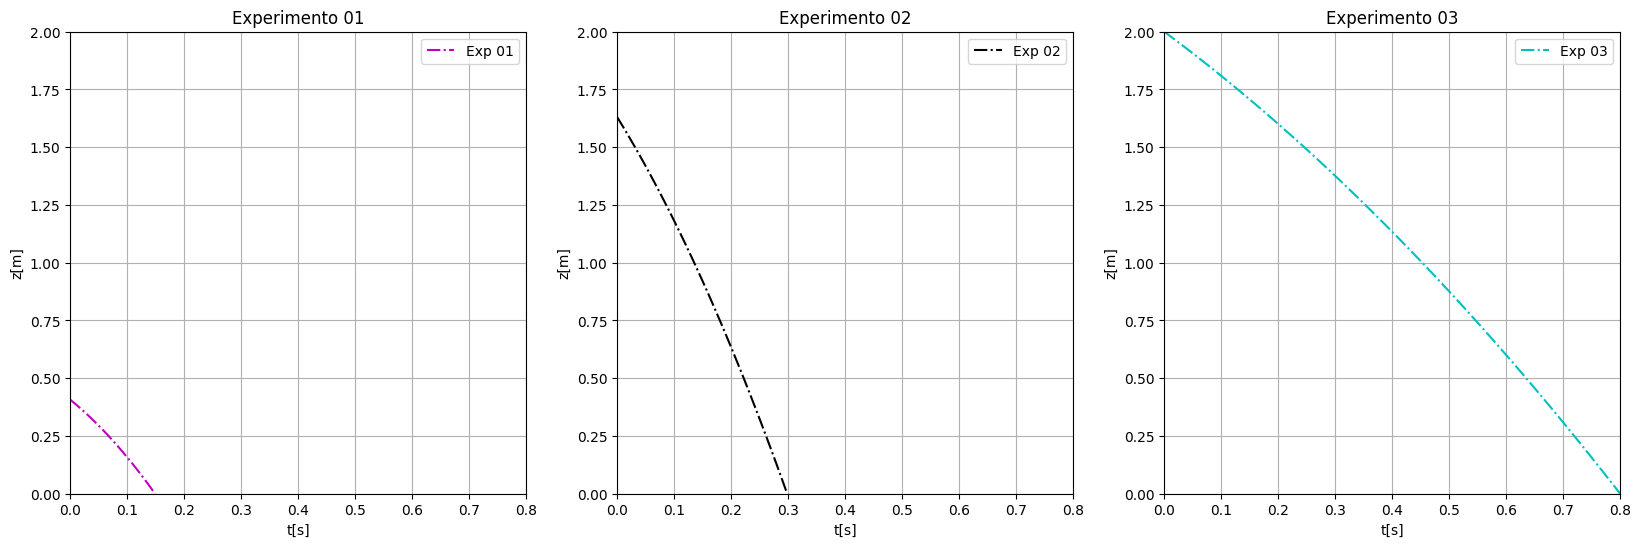

In [44]:
t1_dim = t_adim1 * tc1
t2_dim = t_adim2 * tc2
t3_dim = t_adim3 * tc3
z1_dim = z_adim1 * zc1
z2_dim = z_adim2 * zc2
z3_dim = z_adim3 * zc3
# Exp 01
fig, ax = plt.subplots(1, 3, figsize = (20,6), dpi=100)
for i in range(3):
  ax[i].grid()
  ax[i].set_title(f'Experimento 0{i+1}')
  ax[i].set_xlim([0,0.8])
  ax[i].set_ylim([0,2])
  ax[i].set_xlabel('t[s]')
  ax[i].set_ylabel('z[m]')
# Exp 01
ax[0].plot(t1_dim, z1_dim, 'm-.', label = 'Exp 01')
ax[0].legend()
# Exp 02
ax[1].plot(t2_dim, z2_dim, 'k-.', label = 'Exp 02')
ax[1].legend()
# Exp 03
ax[2].plot(t3_dim, z3_dim, 'c-.', label = 'Exp 03')
ax[2].legend()





In [45]:
# Paso 06: usamos la función para obtener las posición y el tiempo
t1, z1 = posicion(lista_tf[0], valores_exp[0][1], valores_exp[0][0], valores_exp[0][2])
t2, z2 = posicion(lista_tf[1], valores_exp[1][1], valores_exp[1][0], valores_exp[1][2])
t3, z3 = posicion(lista_tf[2], valores_exp[2][1], valores_exp[2][0], valores_exp[2][2])

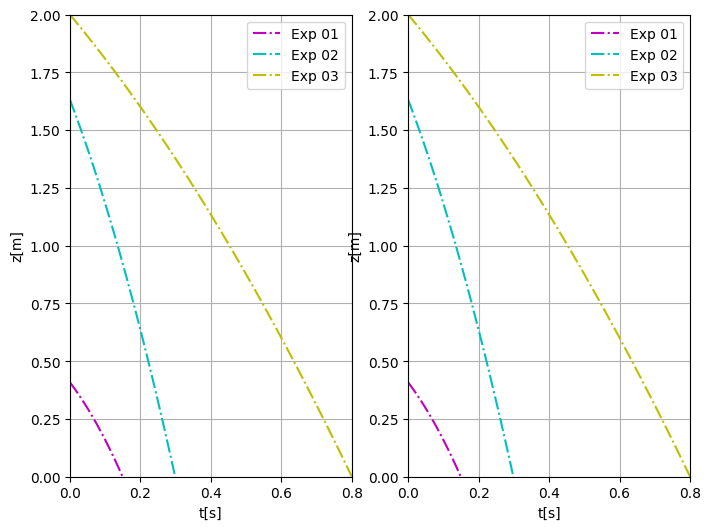

In [46]:
# Paso 07: Graficamos (Todo en una sola gráfica)
fig, ax = plt.subplots(1, 2, figsize = (8,6), dpi=100)
ax[0].plot(t1, z1, 'm-.', label = 'Exp 01')
ax[0].plot(t2, z2, 'c-.', label = 'Exp 02')
ax[0].plot(t3, z3, 'y-.', label = 'Exp 03')
ax[1].plot(t1_dim, z1_dim, 'm-.', label = 'Exp 01')
ax[1].plot(t2_dim, z2_dim, 'c-.', label = 'Exp 02')
ax[1].plot(t3_dim, z3_dim, 'y-.', label = 'Exp 03')
ax[0].set_xlabel('t[s]')
ax[0].set_ylabel('z[m]')
ax[0].set_xlim([0,0.8])
ax[0].set_ylim([0,2])
ax[0].legend()
ax[0].grid()
ax[1].set_xlabel('t[s]')
ax[1].set_ylabel('z[m]')
ax[1].set_xlim([0,0.8])
ax[1].set_ylim([0,2])
ax[1].legend()
ax[1].grid()

<div align='justify'> De este modo comprobamos que de una gráfica adimensional, podíamos obtener las tres gráficas dimensionales solicitadas por la empresa.</div>


### Condensa el número de parámetros del problema

<div align='justify'> Como pudimos comprobar en este "corto" caso de estudio, la adimensionalización de la ecuación de movimiento permitió la reducción del número de parámetros. El problema original contenía una variable independiente $t$, una variable dependiente $z$ y tres parámetros dimensionales: $z_0$, $w_0$ y $g$. El problema adimensional contiene un parámetro independiente $t^*$, un parámetro dependiente $z^*$ y un parámetro adicional: ${Fr}^2$. En otras palabras, disminuye el número de experimentos requeridos, ya sea computacionales o físicos, para caracterizar el fenómenos en cuestión. ¡Lo acabamos de comprobar!, tan sólo un experimento con ${Fr}^2 = 1.0$ condensa muchos experimentos dimensionales.</div>


<div class="alert alert-block alert-warning">
<b> Por último, quisiera proponerle que desarrollen una gráfica que contenga varias curvas $z^*$ vs $t^*$ a distintos números de Froude</b>
</div>

In [47]:
print(plt.style.available) # conocer estilos de graficas (with plt.style.context("dark_background"):)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


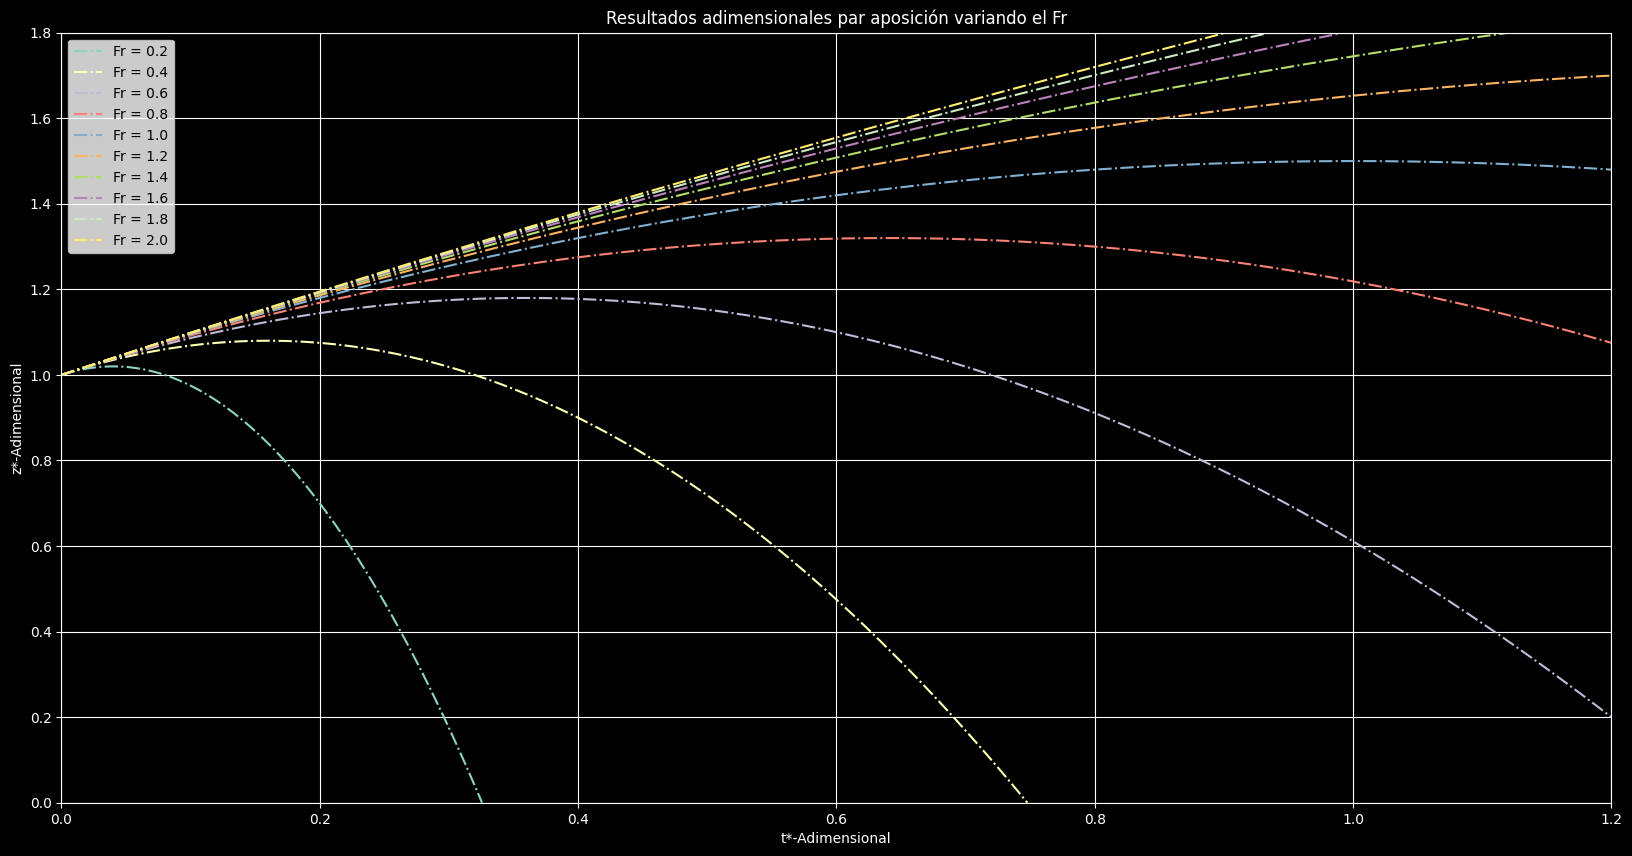

In [48]:
# Paso 01: Creamos nuestro vector de número de Froude
df = 0.2
Froude = np.arange(0.2, 2.0 + df, df)
# Paso 02: Creamos nuestra figura
with plt.style.context('dark_background'):
  fig, ax = plt.subplots(1, 1, figsize = (20,10) )
  w0 = 2.0
  g= 9.81
  # Paso 03: Recorremos el vector Froude
  for Fr in Froude:
      # Paso 04: Ingresamos el valor del Froude en la función caida_libre
      z_adim, t_adim, tf, zc, tc = caida_libre_an(Fr,2.0,g)

      # Paso 05: Graficamos poniendo el label
      ax.plot(t_adim, z_adim, '-.', label = f'Fr = {Fr:.1f}')

  # Paso 06: Ponemos títulos a la gráfica y a los ejes
  ax.set_title('Resultados adimensionales par aposición variando el Fr')
  ax.set_xlabel('t*-Adimensional')
  ax.set_ylabel('z*-Adimensional')

  # Paso 07: Maquillamos la gráfica con limites, grid, ...etc
  plt.style.use("default")
  ax.set_ylim([0.0, 1.8])
  ax.set_xlim([0.0, 1.2])
  ax.grid()
  ax.legend()


### Caracterizar el fenómenos
<div align='justify'> Los números adimensionales permiten capturar características importantes del fenómeno en estudio. En este caso, el número de Froude captura la relación entre las fuerzas inerciales y las gravitacionales. Si la relación es mayor a 1.0, con $w_0 > 0$, entonces las fuerzas inerciales son mayores; pero si la relación es menor a 1.0 con $w_0 > 0$, significa que las fuerzas gravitacionales son mayores. Dentro de esta relación encontramos una información adicional de caracter cualitativa: entre mayor sea el número de Froude, mayor será el tiempo de vuelo.</div>

